[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pycroscopy/asyncroscopy/blob/dev-ACH/notebooks/09_Hackathon_Digital_Twin.ipynb)

# Hackathon Digital Twin

This notebook is a guided workshop built around a simulated scanning diffraction experiment. The opening sections are worked examples: connect to the instrument, acquire HAADF and diffraction data, segment the particles, and recover one local lattice parameter. The open-ended hackathon exercises begin after those examples.

The twin contains round and oval FCC nanoparticles viewed along the `<100>` zone-axis family. Beam position controls the local structure seen by abTEM.

## Google Colab setup

In Colab, run the next three cells once and wait for the server cell to report that every service is ready. The setup clones the workshop branch, creates a Python 3.12 project environment with `uv`, installs the small client layer into the Colab kernel, and enables interactive Matplotlib figures.

Colab storage is temporary: rerun these cells after a runtime reset. Local users should skip them and follow **Local setup** below.

In [1]:
# Local execution: intentionally skip the Colab clone/environment setup.
print("Colab setup skipped; using the existing local project environment.")


Colab setup skipped; using the existing local project environment.


In [2]:
# Local execution: services are pre-existing and must not be started, stopped, or reconfigured.
print("Using the already-running diffraction twin, MCP server, and Tiled server.")


Using the already-running diffraction twin, MCP server, and Tiled server.


## Local setup (skip in Colab)

From the repository root, start the diffraction twin, Tango devices, and Tiled server in a terminal:

```bash
uv run python startup_scripts/run_servers.py --yaml configs/diffraction.yaml
```

Leave that terminal running while you use this notebook. Jupyter and the device servers must run on the same machine for the `localhost` addresses below to work.

## Connect to the digital twin

### Imports

In [3]:
import os
import json
import numpy as np
from pprint import pprint
import matplotlib.pyplot as plt
from tiled.client import from_uri
from pathlib import Path
from fastmcp import Client

%matplotlib inline


### Connect to the live MCP server

All microscope actions in this notebook go through the configured streamable-HTTP MCP server. Tiled is used separately for full numerical arrays.


In [4]:
MCP_URL = "http://127.0.0.1:8000/mcp"
TILED_URL = "http://127.0.0.1:9091"

mcp_client = Client(MCP_URL)
await mcp_client.__aenter__()


async def mcp_action(tool_name, arguments=None):
    result = await mcp_client.call_tool(tool_name, arguments or {})
    if result.is_error:
        raise RuntimeError(f"MCP tool {tool_name} failed: {result.content}")
    if result.data is not None:
        return result.data
    if result.structured_content and "result" in result.structured_content:
        return result.structured_content["result"]
    return None


available_tools = {tool.name for tool in await mcp_client.list_tools()}
required_tools = {
    "DigitalTwinDiffraction_acquire_scanned_image",
    "DigitalTwinDiffraction_acquire_camera_image",
    "DigitalTwinDiffraction_place_beam",
}
missing_tools = required_tools - available_tools
if missing_tools:
    raise RuntimeError(f"Required live MCP tools are missing: {sorted(missing_tools)}")

devices = await mcp_action("list_devices")
print(f"MCP: {MCP_URL}")
print(f"Available devices: {devices}")
print("Required acquisition tools verified.")


MCP: http://127.0.0.1:8000/mcp
Available devices: ['asyncroscopy/camera/default', 'asyncroscopy/data/default', 'asyncroscopy/eds/default', 'asyncroscopy/instrument/default', 'asyncroscopy/scan/default', 'asyncroscopy/stage/default']
Required acquisition tools verified.


### Connect to Tiled

Acquisition commands return a key. Tiled uses that key to retrieve the saved array and its metadata.

In [5]:
config = {"uri": TILED_URL}
config


{'uri': 'http://127.0.0.1:9091'}

In [6]:
client = from_uri(config["uri"])
print(f"Tiled: {config['uri']} | existing entries: {len(client)}")


Tiled: http://127.0.0.1:9091 | existing entries: 191


## Instrument tour

### Acquire a HAADF overview

In [7]:
key = await mcp_action(
    "DigitalTwinDiffraction_acquire_scanned_image",
    {"detector_list": ["HAADF"]},
)
key


'stem_image_HAADF_20260730T170451858288.h5'

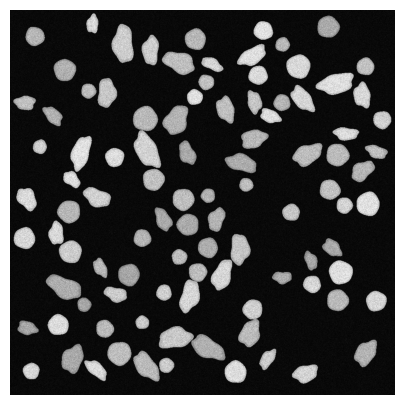

In [8]:
haadf_image = client[key]['image']['HAADF'].read()
metadata = dict(client[key]['image'].metadata)

plt.figure(figsize=(5, 5))
plt.imshow(haadf_image, cmap='gray')
plt.axis('off');

### Park the probe on a particle

Beam positions are fractional `(x, y)` coordinates in `[0, 1]`. The red marker shows where the next local diffraction measurement will be taken.

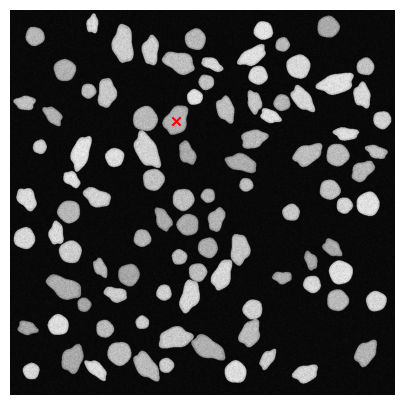

In [9]:
position = [440/1024, 296/1024]
await mcp_action("DigitalTwinDiffraction_place_beam", {"position": position})

plt.figure(figsize=(5, 5))
plt.imshow(haadf_image, cmap='gray')
plt.scatter(position[0]*haadf_image.shape[1], position[1]*haadf_image.shape[0], color='red', marker='x')
plt.axis('off');


### Acquire a local diffraction pattern

A beam parked on a particle produces an abTEM diffraction pattern. A beam parked on the substrate produces the vacuum direct beam. Both acquisitions are saved through the same camera and Tiled path.

In [10]:
key = await mcp_action("DigitalTwinDiffraction_acquire_camera_image")
key


'diffraction_BM-Ceta_20260730T170452987575.h5'

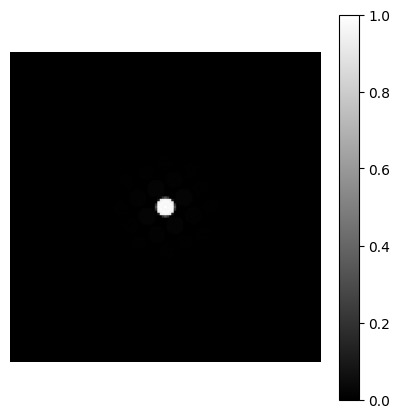

In [11]:
image = client[key]['image'].read()
metadata = dict(client[key]['image'].metadata)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.colorbar()

## Worked example: characterize particles from HAADF

Before choosing diffraction positions, extract useful structure from a fresh `1024 × 1024` HAADF overview. The worked example below:

1. segments all particles without OpenCV;
2. measures rotation-invariant size and shape statistics;
3. maps each statistic back onto the overview;
4. provides features that can guide later sampling decisions.

Diffraction is the expensive measurement, so this overview is the information used to decide where to spend the acquisition budget. The later adaptive exercise is inspired by local diffraction-pattern similarity and clustering ideas in [this paper](https://academic.oup.com/mam/article/32/3/ozag044/8701498).

### Acquire a calibrated `1024 × 1024` overview

The twin has a fixed `500 nm` field of view and saves the pixel size with every HAADF acquisition. Read that calibration from metadata instead of hard-coding it.

In [12]:
# Acquire through MCP; read the complete calibrated array through Tiled.
overview_key = await mcp_action(
    "DigitalTwinDiffraction_acquire_scanned_image",
    {"detector_list": ["HAADF"]},
)
overview_node = client[overview_key]['image']['HAADF']
overview = np.asarray(overview_node.read(), dtype=np.float32)
overview_metadata = dict(overview_node.metadata)

fov_nm = float(overview_metadata.get('fov_nm', 500.0))
pixel_size_nm = float(overview_metadata.get('pixel_size_nm', fov_nm / overview.shape[0]))

print(f'key: {overview_key}')
print(f'image shape: {overview.shape}')
print(f'pixel size: {pixel_size_nm:.3f} nm / pixel')


key: stem_image_HAADF_20260730T170453290648.h5
image shape: (1024, 1024)
pixel size: 0.488 nm / pixel


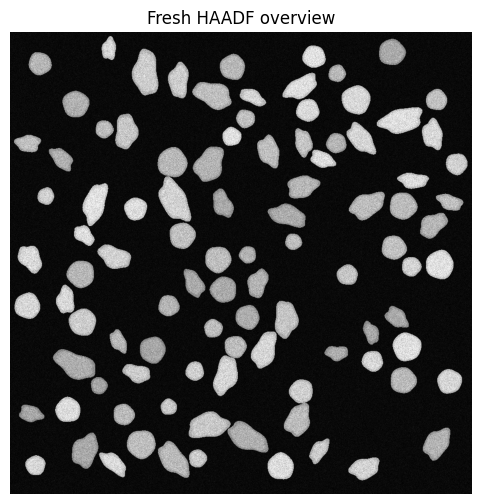

In [13]:
overview_norm = overview - np.nanmin(overview)
if np.nanmax(overview_norm) > 0:
    overview_norm = overview_norm / np.nanmax(overview_norm)

plt.figure(figsize=(6, 6))
plt.imshow(overview_norm, cmap='gray')
plt.title('Fresh HAADF overview')
plt.axis('off');

### Step 1: segment the overview

The example uses Otsu thresholding implemented with NumPy, followed by light cleanup with `scipy.ndimage`. No OpenCV is required.

As you inspect the result, ask: does the threshold preserve the full particle boundary? Would the same cleanup work if two particles touched?

In [14]:
from scipy import ndimage
import pandas as pd
from matplotlib import colors

smoothed = ndimage.gaussian_filter(overview_norm, sigma=0.8)
hist, bin_edges = np.histogram(smoothed.ravel(), bins=256, range=(0.0, 1.0))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
weight_bg = np.cumsum(hist)
weight_fg = hist.sum() - weight_bg
sum_bg = np.cumsum(hist * bin_centers)
sum_fg = np.sum(hist * bin_centers) - sum_bg
valid = (weight_bg > 0) & (weight_fg > 0)
between_class_variance = np.zeros_like(bin_centers)
between_class_variance[valid] = weight_bg[valid] * weight_fg[valid] * (sum_bg[valid] / weight_bg[valid] - sum_fg[valid] / weight_fg[valid]) ** 2
otsu_value = float(bin_centers[int(np.argmax(between_class_variance))])

foreground = smoothed >= otsu_value
foreground = ndimage.binary_opening(foreground, structure=np.ones((2, 2), dtype=bool))
labels, label_count = ndimage.label(foreground, structure=np.ones((3, 3), dtype=bool))

print(f'Otsu threshold: {otsu_value:.3f}')
print(f'raw connected components: {label_count}')

Otsu threshold: 0.381
raw connected components: 96


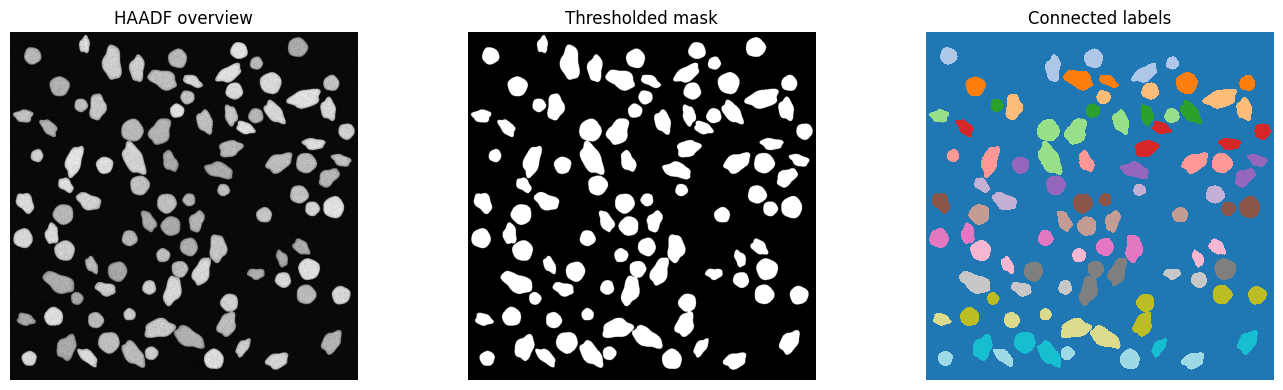

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(overview_norm, cmap='gray')
axes[0].set_title('HAADF overview')
axes[0].axis('off')

axes[1].imshow(foreground, cmap='gray')
axes[1].set_title('Thresholded mask')
axes[1].axis('off')

axes[2].imshow(labels, cmap='tab20', interpolation='nearest')
axes[2].set_title('Connected labels')
axes[2].axis('off')
plt.tight_layout()

### Step 2: compute rotation-invariant particle statistics

Each connected label receives size, center, and shape measurements. Rotation-invariant descriptors are useful because oval particles can point in any in-plane direction.

The table includes:

- area in pixels and `nm²`;
- equivalent radius and center of mass;
- `rmin` and `rmax`, measured from the center to the boundary;
- `rmax / rmin`, a simple orientation-independent irregularity score;
- covariance aspect ratio;
- circularity and radial coefficient of variation.

In [16]:
min_area_px = max(12, int(0.00002 * overview.size))
centroids_yx = ndimage.center_of_mass(np.ones_like(labels, dtype=np.float32), labels, range(1, label_count + 1))
particle_rows = []
filtered_labels = np.zeros_like(labels, dtype=np.int32)
next_label = 1

for label_id, centroid_yx in zip(range(1, label_count + 1), centroids_yx):
    mask = labels == label_id
    area_px = int(np.count_nonzero(mask))
    if area_px < min_area_px or not np.all(np.isfinite(centroid_yx)):
        continue

    cy, cx = centroid_yx
    boundary = mask & ~ndimage.binary_erosion(mask, structure=np.ones((3, 3), dtype=bool), border_value=0)
    boundary_yx = np.column_stack(np.nonzero(boundary)).astype(np.float32)
    if len(boundary_yx) == 0:
        continue

    boundary_xy = boundary_yx[:, ::-1]
    boundary_dist_px = np.sqrt((boundary_xy[:, 0] - cx) ** 2 + (boundary_xy[:, 1] - cy) ** 2)
    rmin_px = float(np.min(boundary_dist_px))
    rmax_px = float(np.max(boundary_dist_px))

    yx = np.column_stack(np.nonzero(mask)).astype(np.float32)
    xy = yx[:, ::-1]
    centered = xy - np.array([[cx, cy]], dtype=np.float32)
    cov = np.cov(centered, rowvar=False) if len(centered) > 2 else np.eye(2)
    eigvals = np.sort(np.linalg.eigvalsh(cov))
    aspect_ratio = float(np.sqrt(eigvals[-1] / max(eigvals[0], 1e-9)))

    padded = np.pad(mask.astype(np.int8), 1)
    perimeter_px = float(np.sum(np.abs(np.diff(padded, axis=0))) + np.sum(np.abs(np.diff(padded, axis=1))))
    circularity = float(4 * np.pi * area_px / max(perimeter_px ** 2, 1e-9))
    radial_cv = float(np.std(boundary_dist_px) / max(np.mean(boundary_dist_px), 1e-9))

    filtered_labels[mask] = next_label
    particle_rows.append({
        'label': next_label,
        'area_px': area_px,
        'area_nm2': area_px * pixel_size_nm ** 2,
        'com_x_px': float(cx),
        'com_y_px': float(cy),
        'equivalent_radius_nm': float(np.sqrt(area_px / np.pi) * pixel_size_nm),
        'rmin_nm': rmin_px * pixel_size_nm,
        'rmax_nm': rmax_px * pixel_size_nm,
        'rmax_over_rmin': rmax_px / max(rmin_px, 1e-9),
        'radial_cv': radial_cv,
        'aspect_ratio_cov': aspect_ratio,
        'circularity': circularity,
    })
    next_label += 1

particle_stats = pd.DataFrame(particle_rows).sort_values('area_px', ascending=False).reset_index(drop=True)
particle_stats.head(12)

,label,area_px,area_nm2,com_x_px,com_y_px,equivalent_radius_nm,rmin_nm,rmax_nm,rmax_over_rmin,radial_cv,aspect_ratio_cov,circularity
0,28,7947,1894.712448,362.113250,336.751856,24.558211,2.311471,43.623612,18.872659,0.475598,2.852423,0.271937
1,70,5312,1266.479492,485.188630,738.069465,20.078171,7.500121,34.745304,4.632632,0.412408,3.051695,0.307395
2,80,5241,1249.551773,641.131654,832.845640,19.943537,2.817154,31.157778,11.060020,0.444228,2.671036,0.308560
3,4,4452,1061.439514,300.730009,90.326370,18.381150,10.893288,26.244810,2.409264,0.224521,1.857717,0.526417
4,16,4129,984.430313,867.025672,195.331315,17.701805,12.042039,26.889157,2.232941,0.228455,1.866836,0.494271
5,73,4093,975.847244,144.026631,736.938187,17.624467,10.406181,25.207858,2.422393,0.235298,1.888734,0.489961
6,85,3982,949.382782,438.913360,871.980663,17.383841,11.728268,24.145330,2.058729,0.188288,1.644760,0.534402
7,86,3923,935.316086,526.282437,898.718073,17.254575,10.514097,25.835237,2.457200,0.234588,1.887223,0.481425
8,27,3777,900.506973,441.925338,292.639132,16.930454,11.936514,21.562114,1.806399,0.146035,1.405691,0.527369
9,10,3740,891.685486,449.635561,139.032086,16.847323,11.259264,22.715225,2.017470,0.191157,1.634212,0.529235


Text(0.5, 0.98, '96 particles: spatial statistics and size trends')

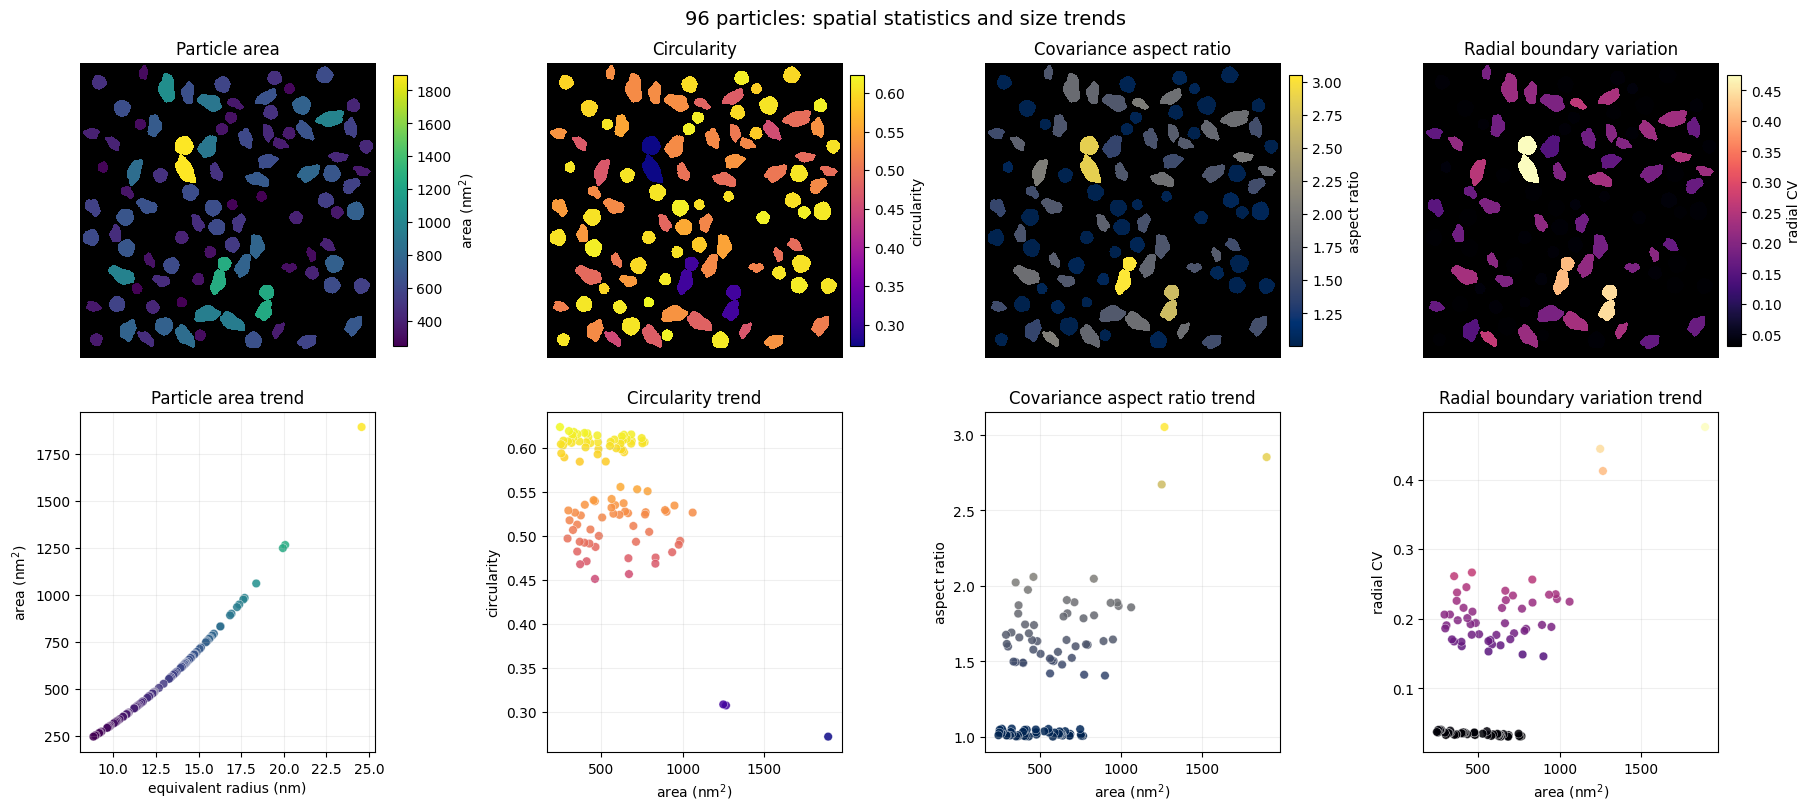

In [17]:
stat_panels = [
    {
        'key': 'area_nm2',
        'title': 'Particle area',
        'ylabel': 'area (nm$^2$)',
        'xkey': 'equivalent_radius_nm',
        'xlabel': 'equivalent radius (nm)',
        'cmap': 'viridis',
    },
    {
        'key': 'circularity',
        'title': 'Circularity',
        'ylabel': 'circularity',
        'xkey': 'area_nm2',
        'xlabel': 'area (nm$^2$)',
        'cmap': 'plasma',
    },
    {
        'key': 'aspect_ratio_cov',
        'title': 'Covariance aspect ratio',
        'ylabel': 'aspect ratio',
        'xkey': 'area_nm2',
        'xlabel': 'area (nm$^2$)',
        'cmap': 'cividis',
    },
    {
        'key': 'radial_cv',
        'title': 'Radial boundary variation',
        'ylabel': 'radial CV',
        'xkey': 'area_nm2',
        'xlabel': 'area (nm$^2$)',
        'cmap': 'magma',
    },
]

fig, axes = plt.subplots(2, len(stat_panels), figsize=(18, 8), constrained_layout=True)
particle_labels = particle_stats['label'].to_numpy(dtype=int)

for column, panel in enumerate(stat_panels):
    values = particle_stats[panel['key']].to_numpy(dtype=float)
    value_by_label = np.full(int(filtered_labels.max()) + 1, np.nan, dtype=float)
    value_by_label[particle_labels] = values
    statistic_image = np.ma.masked_where(filtered_labels == 0, value_by_label[filtered_labels])

    vmin, vmax = float(np.nanmin(values)), float(np.nanmax(values))
    if np.isclose(vmin, vmax):
        vmin, vmax = vmin - 0.5, vmax + 0.5
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.colormaps[panel['cmap']].copy()
    cmap.set_bad('black')

    image_ax = axes[0, column]
    image = image_ax.imshow(statistic_image, cmap=cmap, norm=norm, interpolation='nearest')
    image_ax.set_title(panel['title'])
    image_ax.axis('off')
    fig.colorbar(image, ax=image_ax, fraction=0.046, pad=0.03, label=panel['ylabel'])

    scatter_ax = axes[1, column]
    scatter_ax.scatter(
        particle_stats[panel['xkey']],
        values,
        c=values,
        cmap=cmap,
        norm=norm,
        s=38,
        alpha=0.85,
        edgecolors='white',
        linewidths=0.3,
    )
    scatter_ax.set_xlabel(panel['xlabel'])
    scatter_ax.set_ylabel(panel['ylabel'])
    scatter_ax.set_title(f"{panel['title']} trend")
    scatter_ax.grid(alpha=0.2)

fig.suptitle(f'{len(particle_stats)} particles: spatial statistics and size trends', fontsize=14)


## Worked example: recover one local lattice parameter

The digital twin has two deliberately different lattice profiles:

- **Round particles:** center value `a₀ ~ N(4.078 Å, 0.015 Å)`, smoothly contracting to `0.75 a₀` at the boundary.
- **Oval particles:** center value `a₀ ~ N(4.678 Å, 0.015 Å)`, smoothly expanding to `1.25 a₀` at the boundary.

All particles are FCC and viewed along the `<100>` zone-axis family. The first allowed reflection is therefore `{200}`. The next cell works through direct-beam extraction, Richardson–Lucy deconvolution, radial integration, peak finding, and conversion from the `{200}` angle to `a`.

### Analyze one crystalline diffraction pattern

The example selects the largest segmented particle and parks the beam near its center. Follow each intermediate plot before using the compact function in the exercises.

diffraction key: diffraction_BM-Ceta_20260730T170455413355.h5
angular pixel size: 0.1562 mrad / pixel
first {200} peak: 7.818 mrad
estimated FCC lattice parameter: 6.416 Å


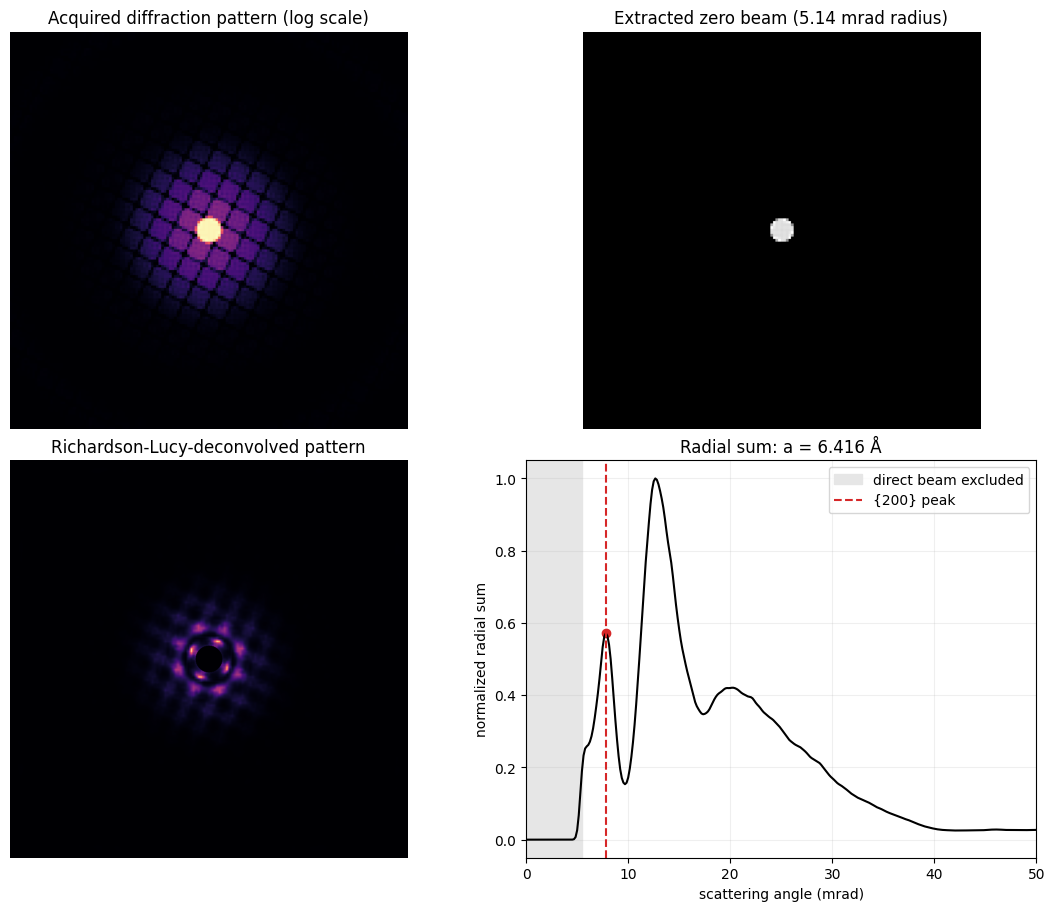

In [18]:
# Acquire a diffraction pattern via MCP and read its full array from Tiled.
target_particle = particle_stats.iloc[0]
beam_position = [
    float(target_particle['com_x_px'] / (overview.shape[1] - 1)),
    float(target_particle['com_y_px'] / (overview.shape[0] - 1)),
]

await mcp_action("DigitalTwinDiffraction_place_beam", {"position": beam_position})
diffraction_key = await mcp_action("DigitalTwinDiffraction_acquire_camera_image")
diffraction_node = client[diffraction_key]['image']
diffraction_pattern = np.asarray(diffraction_node.read(), dtype=np.float64)
diffraction_metadata = dict(diffraction_node.metadata)
pixel_size_mrad = float(diffraction_metadata['pixel_size_mrad'])


# Threshold the central disk to isolate the zero beam.
yy, xx = np.indices(diffraction_pattern.shape, dtype=float)
image_cy = (diffraction_pattern.shape[0] - 1) / 2
image_cx = (diffraction_pattern.shape[1] - 1) / 2
radius_from_image_center = np.hypot(xx - image_cx, yy - image_cy)
central_roi = radius_from_image_center < 0.08 * min(diffraction_pattern.shape)
zero_beam_threshold = 0.5 * float(diffraction_pattern[central_roi].max())
zero_beam_candidates = central_roi & (diffraction_pattern >= zero_beam_threshold)

candidate_labels, _ = ndimage.label(zero_beam_candidates)
center_label = candidate_labels[int(round(image_cy)), int(round(image_cx))]
zero_beam_mask = ndimage.binary_fill_holes(candidate_labels == center_label)

zero_beam_weights = np.where(zero_beam_mask, diffraction_pattern, 0.0)
beam_cy = float(np.sum(yy * zero_beam_weights) / np.sum(zero_beam_weights))
beam_cx = float(np.sum(xx * zero_beam_weights) / np.sum(zero_beam_weights))
radius_px = np.hypot(xx - beam_cx, yy - beam_cy)
zero_beam_radius_px = float(np.percentile(radius_px[zero_beam_mask], 99))

from scipy import constants, signal

beam_y, beam_x = np.nonzero(zero_beam_mask)
padding = 2
point_spread_function = zero_beam_weights[
    max(0, beam_y.min() - padding):beam_y.max() + padding + 1,
    max(0, beam_x.min() - padding):beam_x.max() + padding + 1,
]
point_spread_function /= np.sum(point_spread_function)
reflected_psf = point_spread_function[::-1, ::-1]
deconvolved = np.full_like(diffraction_pattern, max(float(diffraction_pattern.mean()), 1e-6))

for _ in range(15):
    blurred = signal.fftconvolve(deconvolved, point_spread_function, mode='same')
    relative_blur = diffraction_pattern / np.maximum(blurred, 1e-8)
    deconvolved *= signal.fftconvolve(relative_blur, reflected_psf, mode='same')
    deconvolved = np.clip(deconvolved, 0.0, None)

deconvolved[radius_px <= 1.05 * zero_beam_radius_px] = 0.0
radial_bin = np.floor(radius_px).astype(int)
radial_sum = np.bincount(radial_bin.ravel(), weights=deconvolved.ravel())
radial_sum = ndimage.gaussian_filter1d(radial_sum, sigma=1.5)
radial_angle_mrad = np.arange(len(radial_sum)) * pixel_size_mrad

search_start = int(np.ceil(1.05 * zero_beam_radius_px))
search_stop = min(len(radial_sum), int(np.ceil(50.0 / pixel_size_mrad)))
search_profile = radial_sum[search_start:search_stop]
peak_indices, _ = signal.find_peaks(
    search_profile,
    prominence=0.03 * float(search_profile.max()),
    distance=max(1, int(round(2.0 / pixel_size_mrad))),
)
if len(peak_indices) == 0:
    raise RuntimeError('No Bragg peak found. Try a beam position farther from the particle edge.')

first_peak_bin = int(search_start + peak_indices[0])
left, center, right = radial_sum[first_peak_bin - 1:first_peak_bin + 2]
denominator = left - 2 * center + right
peak_offset = 0.5 * (left - right) / denominator if denominator != 0 else 0.0
first_peak_radius_px = first_peak_bin + float(np.clip(peak_offset, -0.5, 0.5))
first_peak_mrad = first_peak_radius_px * pixel_size_mrad

accelerating_voltage_v = 200_000.0
electron_wavelength_m = constants.h / np.sqrt(
    2 * constants.m_e * constants.e * accelerating_voltage_v
    * (1 + constants.e * accelerating_voltage_v / (2 * constants.m_e * constants.c ** 2))
)
electron_wavelength_angstrom = electron_wavelength_m * 1e10
scattering_angle_rad = first_peak_mrad * 1e-3
d200_angstrom = electron_wavelength_angstrom / (2 * np.sin(scattering_angle_rad / 2))
lattice_parameter_angstrom = 2 * d200_angstrom

print(f'diffraction key: {diffraction_key}')
print(f'angular pixel size: {pixel_size_mrad:.4f} mrad / pixel')
print(f'first {{200}} peak: {first_peak_mrad:.3f} mrad')
print(f'estimated FCC lattice parameter: {lattice_parameter_angstrom:.3f} Å')

fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
axes[0, 0].imshow(np.log1p(1000 * diffraction_pattern), cmap='magma')
axes[0, 0].set_title('Acquired diffraction pattern (log scale)')
axes[0, 0].axis('off')
axes[0, 1].imshow(zero_beam_weights, cmap='gray')
axes[0, 1].set_title(f'Extracted zero beam ({zero_beam_radius_px * pixel_size_mrad:.2f} mrad radius)')
axes[0, 1].axis('off')
axes[1, 0].imshow(np.log1p(deconvolved), cmap='magma')
axes[1, 0].set_title('Richardson-Lucy-deconvolved pattern')
axes[1, 0].axis('off')
radial_sum_normalized = radial_sum / max(float(radial_sum.max()), 1e-12)
axes[1, 1].plot(radial_angle_mrad, radial_sum_normalized, color='black')
axes[1, 1].axvspan(0, radial_angle_mrad[search_start], color='0.9', label='direct beam excluded')
axes[1, 1].axvline(first_peak_mrad, color='tab:red', linestyle='--', label='{200} peak')
axes[1, 1].scatter([first_peak_mrad], [np.interp(first_peak_mrad, radial_angle_mrad, radial_sum_normalized)], color='tab:red')
axes[1, 1].set_xlim(0, min(50, radial_angle_mrad[-1]))
axes[1, 1].set_xlabel('scattering angle (mrad)')
axes[1, 1].set_ylabel('normalized radial sum')
axes[1, 1].set_title(f'Radial sum: a = {lattice_parameter_angstrom:.3f} Å')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.2)


In [19]:
def analyze_lattice_pattern(diff_pattern, pixel_size):
    """Return lattice estimate and peak-quality diagnostics from a full diffraction array."""
    from scipy import constants, ndimage, signal

    pattern = np.asarray(diff_pattern, dtype=float)
    if pattern.ndim != 2 or not np.all(np.isfinite(pattern)) or pattern.max() <= 0:
        raise ValueError('Invalid diffraction array.')

    yy, xx = np.indices(pattern.shape, dtype=float)
    image_cy = (pattern.shape[0] - 1) / 2
    image_cx = (pattern.shape[1] - 1) / 2
    radius = np.hypot(xx - image_cx, yy - image_cy)
    central_roi = radius < 0.08 * min(pattern.shape)
    candidates = central_roi & (pattern >= 0.5 * pattern[central_roi].max())
    labels, _ = ndimage.label(candidates)
    center_label = labels[int(round(image_cy)), int(round(image_cx))]
    if center_label == 0:
        raise ValueError('Direct beam could not be isolated.')
    zero_beam_mask = ndimage.binary_fill_holes(labels == center_label)
    zero_beam = np.where(zero_beam_mask, pattern, 0.0)
    if zero_beam.sum() <= 0:
        raise ValueError('Direct beam has zero intensity.')

    beam_cy = np.sum(yy * zero_beam) / np.sum(zero_beam)
    beam_cx = np.sum(xx * zero_beam) / np.sum(zero_beam)
    radius = np.hypot(xx - beam_cx, yy - beam_cy)
    zero_beam_radius = np.percentile(radius[zero_beam_mask], 99)

    beam_y, beam_x = np.nonzero(zero_beam_mask)
    psf = zero_beam[
        max(0, beam_y.min() - 2):beam_y.max() + 3,
        max(0, beam_x.min() - 2):beam_x.max() + 3,
    ]
    psf /= psf.sum()
    estimate = np.full_like(pattern, max(float(pattern.mean()), 1e-6))
    for _ in range(15):
        blurred = signal.fftconvolve(estimate, psf, mode='same')
        estimate *= signal.fftconvolve(
            pattern / np.maximum(blurred, 1e-8), psf[::-1, ::-1], mode='same'
        )
        estimate = np.clip(estimate, 0.0, None)

    estimate[radius <= 1.05 * zero_beam_radius] = 0.0
    radial_bin = np.floor(radius).astype(int)
    radial_sum = np.bincount(radial_bin.ravel(), weights=estimate.ravel())
    radial_sum = ndimage.gaussian_filter1d(radial_sum, sigma=1.5)

    search_start = int(np.ceil(1.05 * zero_beam_radius))
    search_stop = min(len(radial_sum), int(np.ceil(50.0 / pixel_size)))
    profile = radial_sum[search_start:search_stop]
    if profile.size < 3 or profile.max() <= 0:
        raise ValueError('No usable intensity outside the direct beam.')
    peaks, properties = signal.find_peaks(
        profile,
        prominence=0.03 * profile.max(),
        distance=max(1, int(round(2.0 / pixel_size))),
    )
    if len(peaks) == 0:
        raise ValueError('No crystalline {200} peak found at this beam position.')

    peak_bin = search_start + int(peaks[0])
    left, center, right = radial_sum[peak_bin - 1:peak_bin + 2]
    denominator = left - 2 * center + right
    offset = 0.5 * (left - right) / denominator if denominator != 0 else 0.0
    peak_mrad = (peak_bin + np.clip(offset, -0.5, 0.5)) * pixel_size
    scattering_angle = peak_mrad * 1e-3

    voltage = 200_000.0
    wavelength = constants.h / np.sqrt(
        2 * constants.m_e * constants.e * voltage
        * (1 + constants.e * voltage / (2 * constants.m_e * constants.c**2))
    )
    d200 = wavelength * 1e10 / (2 * np.sin(scattering_angle / 2))
    lattice = float(2 * d200)
    prominence_fraction = float(properties['prominences'][0] / profile.max())
    return {
        'lattice_angstrom': lattice,
        'peak_mrad': float(peak_mrad),
        'prominence_fraction': prominence_fraction,
        'zero_beam_radius_mrad': float(zero_beam_radius * pixel_size),
        'radial_sum': radial_sum,
    }


def get_lattice_param(diff_pattern, pixel_size):
    return analyze_lattice_pattern(diff_pattern, pixel_size)['lattice_angstrom']


## Hackathon exercises

### Exercise 1: compare center-to-edge lattice profiles

Use the particle statistics to choose one round-looking particle and one oval-looking particle. For each particle, sample a radial path from its center toward the edge and call `get_lattice_param` at every crystalline position.

Questions to investigate:

- Can you recover contraction in the round particle and expansion in the oval particle?
- Where does the estimator stop finding a reliable `{200}` peak, and what changes in the pattern there?
- How many measurements are needed to distinguish the two profiles reliably?
- Which HAADF shape statistic best predicts the sign of the lattice gradient?

In [20]:
# Choose strong, isolated HAADF shape extremes without using diffraction metadata.
# Very small center-to-boundary distances or extreme rmax/rmin values flag merged
# connected components; exclude those before selecting one-particle exemplars.
isolated_particles = particle_stats.query(
    "rmin_nm > 8.0 and rmax_over_rmin < 3.0"
).copy()
round_particle = isolated_particles.sort_values(
    ['aspect_ratio_cov', 'radial_cv', 'circularity'],
    ascending=[True, True, False],
).iloc[0]
oval_particle = isolated_particles.sort_values(
    ['aspect_ratio_cov', 'radial_cv'],
    ascending=[False, False],
).iloc[0]

selected_particles = {'round': round_particle, 'oval': oval_particle}
selection_table = pd.DataFrame(selected_particles).T[
    ['label', 'area_nm2', 'aspect_ratio_cov', 'rmax_over_rmin', 'radial_cv', 'circularity']
]
selection_table


,label,area_nm2,aspect_ratio_cov,rmax_over_rmin,radial_cv,circularity
round,81.0,580.072403,1.001446,1.168895,0.031747,0.609335
oval,34.0,832.080841,2.046972,2.537311,0.256364,0.468374


In [21]:
from scipy import stats
from IPython.display import Markdown, display


def radial_path_for_particle(row, fractions):
    label = int(row['label'])
    mask = filtered_labels == label
    boundary = mask & ~ndimage.binary_erosion(mask, structure=np.ones((3, 3), dtype=bool))
    boundary_yx = np.column_stack(np.nonzero(boundary)).astype(float)
    center_yx = np.array([row['com_y_px'], row['com_x_px']], dtype=float)
    edge_yx = boundary_yx[np.argmax(np.linalg.norm(boundary_yx - center_yx, axis=1))]
    direction = edge_yx - center_yx
    return center_yx[None, :] + np.asarray(fractions)[:, None] * direction[None, :]


profile_fractions = np.array([0.00, 0.12, 0.24, 0.36, 0.48, 0.60, 0.72, 0.84, 0.92, 1.08])
profile_rows = []
profile_patterns = {}
profile_paths = {}

for haadf_class, particle in selected_particles.items():
    path_yx = radial_path_for_particle(particle, profile_fractions)
    profile_paths[haadf_class] = path_yx
    center_acquired_kind = None

    for fraction, (row_px, column_px) in zip(profile_fractions, path_yx):
        beam_position = [
            float(np.clip(column_px / (overview.shape[1] - 1), 0, 1)),
            float(np.clip(row_px / (overview.shape[0] - 1), 0, 1)),
        ]
        await mcp_action("DigitalTwinDiffraction_place_beam", {"position": beam_position})
        acquisition_key = await mcp_action("DigitalTwinDiffraction_acquire_camera_image")
        node = client[acquisition_key]['image']
        pattern = np.asarray(node.read(), dtype=np.float64)
        metadata = dict(node.metadata)
        acquired_kind = metadata.get('particle_kind')
        if center_acquired_kind is None and acquired_kind is not None:
            center_acquired_kind = str(acquired_kind)

        diagnostic = None
        error = None
        try:
            diagnostic = analyze_lattice_pattern(pattern, float(metadata['pixel_size_mrad']))
        except Exception as exc:
            error = str(exc)

        same_particle_kind = acquired_kind is not None and str(acquired_kind) == center_acquired_kind
        reliable = bool(
            diagnostic is not None
            and same_particle_kind
            and 3.0 <= diagnostic['lattice_angstrom'] <= 6.2
            and diagnostic['prominence_fraction'] >= 0.03
        )
        profile_rows.append({
            'haadf_class': haadf_class,
            'acquired_kind': acquired_kind if acquired_kind is not None else 'noncrystalline',
            'fraction_to_edge': float(fraction),
            'distance_nm': float(
                np.linalg.norm(np.array([row_px, column_px]) - path_yx[0]) * pixel_size_nm
            ),
            'lattice_angstrom': diagnostic['lattice_angstrom'] if reliable else np.nan,
            'metadata_lattice_angstrom': metadata.get('particle_lattice_parameter_angstrom', np.nan),
            'peak_mrad': diagnostic['peak_mrad'] if diagnostic else np.nan,
            'prominence_fraction': diagnostic['prominence_fraction'] if diagnostic else 0.0,
            'reliable': reliable,
            'key': acquisition_key,
            'error': error,
        })
        profile_patterns[(haadf_class, float(fraction))] = pattern

profile_data = pd.DataFrame(profile_rows)
profile_data


,haadf_class,acquired_kind,fraction_to_edge,distance_nm,lattice_angstrom,metadata_lattice_angstrom,peak_mrad,prominence_fraction,reliable,key,error
0,round,round,0.00,0.000000,4.157957,4.081046,12.063374,0.995436,True,diffraction_BM-Ceta_20260730T170457066356.h5,None
1,round,round,0.12,1.713799,4.064088,4.047357,12.342006,0.994881,True,diffraction_BM-Ceta_20260730T170457814037.h5,None
2,round,round,0.24,3.427598,4.004863,3.926140,12.524524,0.996375,True,diffraction_BM-Ceta_20260730T170458586598.h5,None
3,round,round,0.36,5.141397,3.850634,3.793437,13.026176,0.997679,True,diffraction_BM-Ceta_20260730T170459269079.h5,None
4,round,round,0.48,6.855195,3.608776,3.592080,13.899196,0.998288,True,diffraction_BM-Ceta_20260730T170459954073.h5,None
5,round,round,0.60,8.568994,3.518731,3.436896,14.254885,0.997958,True,diffraction_BM-Ceta_20260730T170500711534.h5,None
6,round,round,0.72,10.282793,3.330347,3.249688,15.061240,0.998132,True,diffraction_BM-Ceta_20260730T170501410985.h5,None
7,round,round,0.84,11.996592,3.086962,3.139671,16.248739,0.979464,True,diffraction_BM-Ceta_20260730T170502085337.h5,None
8,round,round,0.92,13.139124,NaN,3.074500,5.290364,0.063859,False,diffraction_BM-Ceta_20260730T170502823332.h5,None
9,round,noncrystalline,1.08,15.424190,NaN,NaN,NaN,0.000000,False,diffraction_BM-Ceta_20260730T170503558848.h5,No crystalline {200} peak found at this beam p...


,measurements,center_A,edgeward_A,change_A,change_percent,smoothstep_slope_A,slope_ci_low_A,slope_ci_high_A,metadata_rmse_A
profile,,,,,,,,,
round,8,4.1580,3.0870,-1.0710,-25.7577,-1.0652,-1.1918,-0.9385,0.0632
oval,9,4.4522,6.0067,1.5546,34.9169,1.9163,0.7127,3.1200,0.5642


#### Exercise 1 conclusions (live data)

1. **Opposite profiles recovered.** The round particle changed by **-1.071 Å (-25.8%)**, while the oval particle changed by **+1.555 Å (+34.9%)** from center to the last reliable edgeward point. Their fitted smoothstep slopes were -1.065 Å and +1.916 Å, respectively.
2. **Reliability limit.** The round estimate first failed at normalized radius **0.92**: although the acquisition still had round-particle metadata, the selected radial feature jumped from **16.25 mrad** at the last reliable point to **5.29 mrad**, producing an implausible lattice value. The oval estimate remained reliable through 0.92 and failed at **1.08**, where the beam was noncrystalline. Outside the HAADF boundary the Bragg features disappear and the pattern is dominated by the vacuum direct beam, so no scalar lattice value is assigned.
3. **Observed measurement requirement.** Using the predeclared criterion that both 95% slope confidence intervals exclude zero with opposite signs, the live profiles required **8 measurements per profile**. This is a dataset-specific empirical requirement, not a universal guarantee.
4. **Best HAADF sign predictor here.** **`aspect_ratio_cov`** gave the largest robustly scaled contrast between the two sign-labeled particles (1.63 overview IQRs). With only two diffraction-labeled particles this is a practical selector, not a population-level validation.

The array-derived estimator agreed with the acquired diffraction metadata to RMSEs of **0.063 Å** (round) and **0.564 Å** (oval).


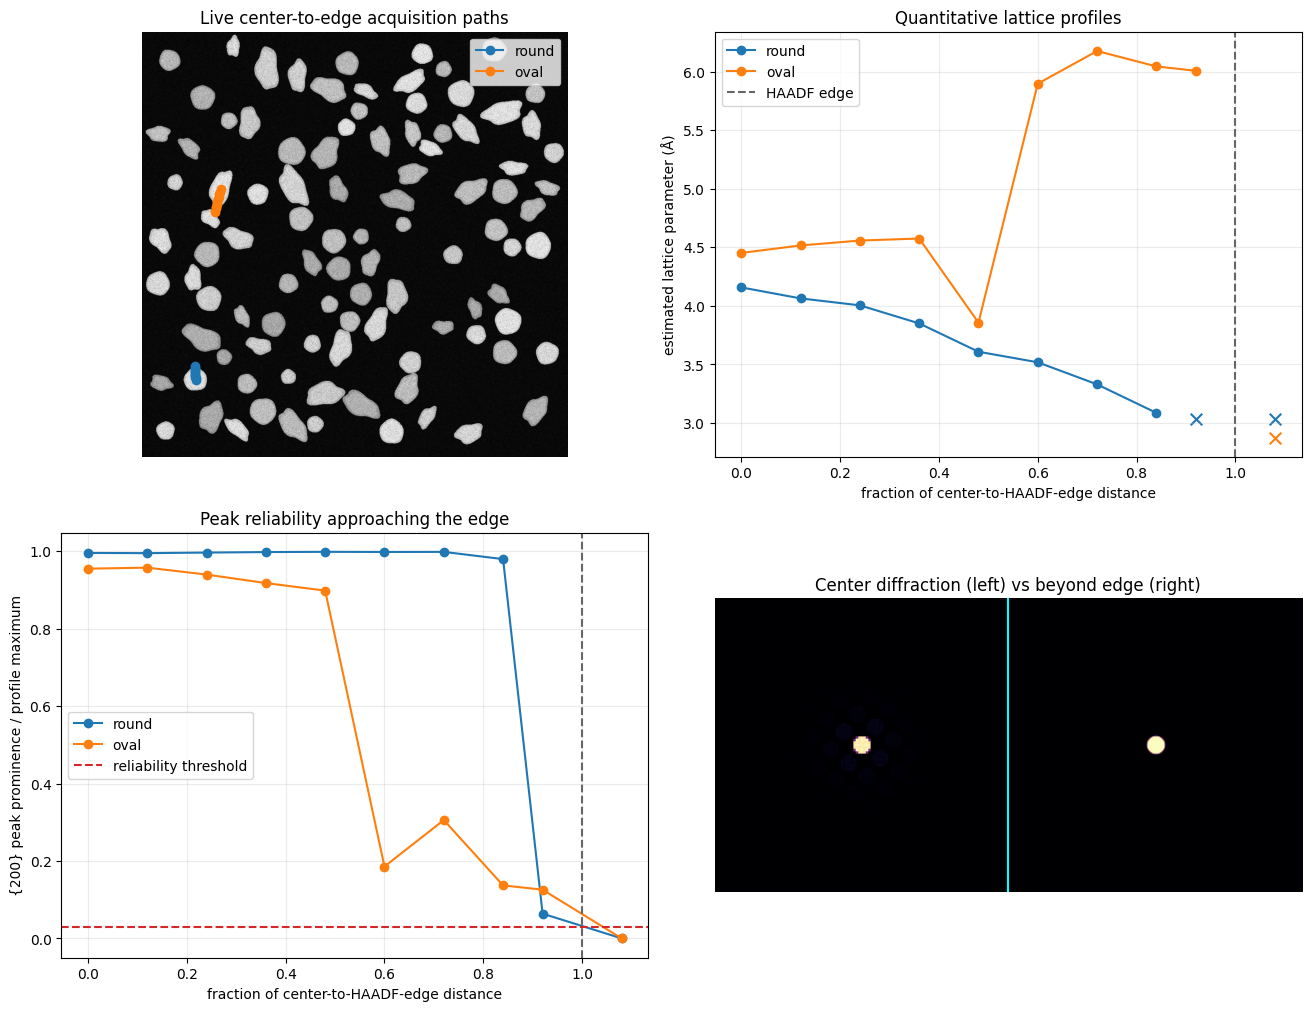

In [22]:
def smoothstep(radius_fraction):
    x = np.clip(np.asarray(radius_fraction, dtype=float), 0, 1)
    return x * x * (3 - 2 * x)


def slope_with_ci(frame):
    x = smoothstep(frame['fraction_to_edge'].to_numpy())
    y = frame['lattice_angstrom'].to_numpy()
    design = np.column_stack([np.ones_like(x), x])
    beta, _, _, _ = np.linalg.lstsq(design, y, rcond=None)
    residual = y - design @ beta
    dof = len(y) - 2
    if dof <= 0:
        return beta[1], np.nan, np.nan
    variance = np.sum(residual**2) / dof
    covariance = variance * np.linalg.inv(design.T @ design)
    standard_error = np.sqrt(covariance[1, 1])
    critical = stats.t.ppf(0.975, dof)
    return float(beta[1]), float(beta[1] - critical * standard_error), float(beta[1] + critical * standard_error)


fit_rows = []
for name in ['round', 'oval']:
    valid = profile_data.query("haadf_class == @name and reliable").sort_values('fraction_to_edge')
    valid = valid[valid['fraction_to_edge'] <= 1.0]
    slope, ci_low, ci_high = slope_with_ci(valid)
    rmse = float(np.sqrt(np.nanmean(
        (valid['lattice_angstrom'] - valid['metadata_lattice_angstrom']) ** 2
    )))
    fit_rows.append({
        'profile': name,
        'measurements': len(valid),
        'center_A': float(valid.iloc[0]['lattice_angstrom']),
        'edgeward_A': float(valid.iloc[-1]['lattice_angstrom']),
        'change_A': float(valid.iloc[-1]['lattice_angstrom'] - valid.iloc[0]['lattice_angstrom']),
        'change_percent': float(100 * (valid.iloc[-1]['lattice_angstrom'] / valid.iloc[0]['lattice_angstrom'] - 1)),
        'smoothstep_slope_A': slope,
        'slope_ci_low_A': ci_low,
        'slope_ci_high_A': ci_high,
        'metadata_rmse_A': rmse,
    })
profile_summary = pd.DataFrame(fit_rows).set_index('profile')

# Progressive 95% slope-CI criterion for the minimum observed measurement count.
minimum_distinguishing_count = None
maximum_common = min(
    len(profile_data.query("haadf_class == 'round' and reliable and fraction_to_edge <= 1")),
    len(profile_data.query("haadf_class == 'oval' and reliable and fraction_to_edge <= 1")),
)
for count in range(3, maximum_common + 1):
    round_subset = profile_data.query(
        "haadf_class == 'round' and reliable and fraction_to_edge <= 1"
    ).sort_values('fraction_to_edge').iloc[:count]
    oval_subset = profile_data.query(
        "haadf_class == 'oval' and reliable and fraction_to_edge <= 1"
    ).sort_values('fraction_to_edge').iloc[:count]
    r_slope, r_low, r_high = slope_with_ci(round_subset)
    o_slope, o_low, o_high = slope_with_ci(oval_subset)
    if np.isfinite([r_low, r_high, o_low, o_high]).all() and r_high < 0 < o_low:
        minimum_distinguishing_count = count
        break

# Compare the two sign-labeled particles using robust whole-overview scaling.
descriptor_directions = {
    'aspect_ratio_cov': 1,
    'rmax_over_rmin': 1,
    'radial_cv': 1,
    'circularity': -1,
}
descriptor_contrast = {}
for descriptor, direction in descriptor_directions.items():
    values = particle_stats[descriptor].to_numpy(float)
    scale = max(float(np.subtract(*np.nanpercentile(values, [75, 25]))), 1e-9)
    descriptor_contrast[descriptor] = direction * (
        float(oval_particle[descriptor]) - float(round_particle[descriptor])
    ) / scale
best_shape_statistic = max(descriptor_contrast, key=descriptor_contrast.get)

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
axes[0, 0].imshow(overview_norm, cmap='gray')
for name, color in [('round', 'tab:blue'), ('oval', 'tab:orange')]:
    path = profile_paths[name]
    axes[0, 0].plot(path[:, 1], path[:, 0], 'o-', color=color, label=name)
axes[0, 0].set_title('Live center-to-edge acquisition paths')
axes[0, 0].legend()
axes[0, 0].axis('off')

for name, color in [('round', 'tab:blue'), ('oval', 'tab:orange')]:
    frame = profile_data.query("haadf_class == @name")
    valid = frame['reliable']
    axes[0, 1].plot(
        frame.loc[valid, 'fraction_to_edge'],
        frame.loc[valid, 'lattice_angstrom'],
        'o-', color=color, label=name,
    )
    axes[0, 1].scatter(
        frame.loc[~valid, 'fraction_to_edge'],
        np.full((~valid).sum(), axes[0, 1].get_ylim()[0] if axes[0, 1].has_data() else 3.0),
        marker='x', s=70, color=color,
    )
axes[0, 1].axvline(1.0, color='0.4', linestyle='--', label='HAADF edge')
axes[0, 1].set_xlabel('fraction of center-to-HAADF-edge distance')
axes[0, 1].set_ylabel('estimated lattice parameter (Å)')
axes[0, 1].set_title('Quantitative lattice profiles')
axes[0, 1].grid(alpha=0.25)
axes[0, 1].legend()

for name, color in [('round', 'tab:blue'), ('oval', 'tab:orange')]:
    frame = profile_data.query("haadf_class == @name")
    axes[1, 0].plot(
        frame['fraction_to_edge'], frame['prominence_fraction'],
        'o-', color=color, label=name,
    )
axes[1, 0].axhline(0.03, color='tab:red', linestyle='--', label='reliability threshold')
axes[1, 0].axvline(1.0, color='0.4', linestyle='--')
axes[1, 0].set_xlabel('fraction of center-to-HAADF-edge distance')
axes[1, 0].set_ylabel('{200} peak prominence / profile maximum')
axes[1, 0].set_title('Peak reliability approaching the edge')
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend()

outside_name = 'round'
center_pattern = profile_patterns[(outside_name, 0.0)]
outside_pattern = profile_patterns[(outside_name, 1.08)]
comparison = np.concatenate([np.log1p(center_pattern), np.log1p(outside_pattern)], axis=1)
axes[1, 1].imshow(comparison, cmap='magma')
axes[1, 1].axvline(center_pattern.shape[1], color='cyan')
axes[1, 1].set_title('Center diffraction (left) vs beyond edge (right)')
axes[1, 1].axis('off')

display(profile_summary.round(4))

first_invalid = {}
for name in ['round', 'oval']:
    failed = profile_data.query("haadf_class == @name and not reliable")
    first_invalid[name] = float(failed['fraction_to_edge'].min()) if len(failed) else np.nan

round_failure = profile_data.query(
    "haadf_class == 'round' and not reliable"
).sort_values('fraction_to_edge').iloc[0]
oval_failure = profile_data.query(
    "haadf_class == 'oval' and not reliable"
).sort_values('fraction_to_edge').iloc[0]
round_last_valid = profile_data.query(
    "haadf_class == 'round' and reliable"
).sort_values('fraction_to_edge').iloc[-1]

minimum_text = (
    f"{minimum_distinguishing_count} measurements per profile"
    if minimum_distinguishing_count is not None
    else f"more than the {maximum_common} reliable measurements acquired per profile"
)
display(Markdown(
    f"""#### Exercise 1 conclusions (live data)

1. **Opposite profiles recovered.** The round particle changed by **{profile_summary.loc['round', 'change_A']:+.3f} Å ({profile_summary.loc['round', 'change_percent']:+.1f}%)**, while the oval particle changed by **{profile_summary.loc['oval', 'change_A']:+.3f} Å ({profile_summary.loc['oval', 'change_percent']:+.1f}%)** from center to the last reliable edgeward point. Their fitted smoothstep slopes were {profile_summary.loc['round', 'smoothstep_slope_A']:+.3f} Å and {profile_summary.loc['oval', 'smoothstep_slope_A']:+.3f} Å, respectively.
2. **Reliability limit.** The round estimate first failed at normalized radius **{first_invalid['round']:.2f}**: although the acquisition still had round-particle metadata, the selected radial feature jumped from **{round_last_valid['peak_mrad']:.2f} mrad** at the last reliable point to **{round_failure['peak_mrad']:.2f} mrad**, producing an implausible lattice value. The oval estimate remained reliable through 0.92 and failed at **{first_invalid['oval']:.2f}**, where the beam was noncrystalline. Outside the HAADF boundary the Bragg features disappear and the pattern is dominated by the vacuum direct beam, so no scalar lattice value is assigned.
3. **Observed measurement requirement.** Using the predeclared criterion that both 95% slope confidence intervals exclude zero with opposite signs, the live profiles required **{minimum_text}**. This is a dataset-specific empirical requirement, not a universal guarantee.
4. **Best HAADF sign predictor here.** **`{best_shape_statistic}`** gave the largest robustly scaled contrast between the two sign-labeled particles ({descriptor_contrast[best_shape_statistic]:.2f} overview IQRs). With only two diffraction-labeled particles this is a practical selector, not a population-level validation.

The array-derived estimator agreed with the acquired diffraction metadata to RMSEs of **{profile_summary.loc['round', 'metadata_rmse_A']:.3f} Å** (round) and **{profile_summary.loc['oval', 'metadata_rmse_A']:.3f} Å** (oval).
"""
))


### Exercise 2: build an adaptive lattice-parameter map

Now reconstruct a two-dimensional lattice map from a small number of diffraction measurements. Treat unmeasured positions as unknown and let disagreement between sparse reconstructions suggest the next beam position.

Start with a modest acquisition budget, watch the reconstruction evolve, and decide when another measurement is no longer worth its cost. Pay attention to locations where a scalar lattice parameter becomes difficult or impossible to assign.

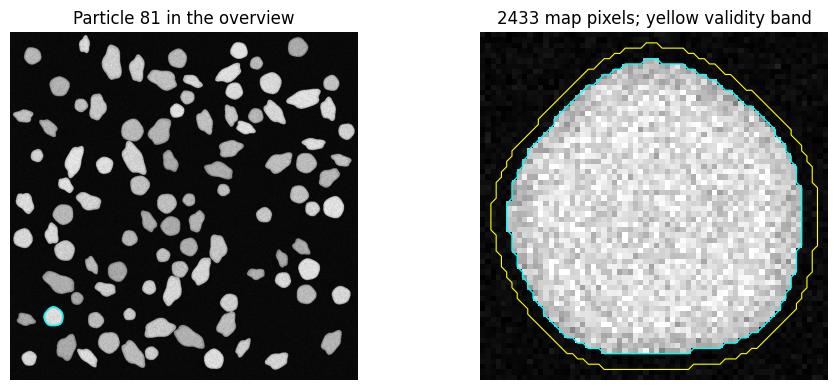

In [23]:
# Map the isolated round-looking particle; its well-resolved {200} peak makes
# uncertainty reflect spatial sampling rather than peak-index ambiguity.
padding = 5
target_label = int(round_particle['label'])
particle_mask = filtered_labels == target_label
particle_rows_px, particle_columns_px = np.nonzero(particle_mask)

row_slice = slice(
    max(0, int(particle_rows_px.min()) - padding),
    min(overview.shape[0], int(particle_rows_px.max()) + padding + 1),
)
column_slice = slice(
    max(0, int(particle_columns_px.min()) - padding),
    min(overview.shape[1], int(particle_columns_px.max()) + padding + 1),
)
region_mask = particle_mask[row_slice, column_slice]
candidate_region = ndimage.binary_dilation(region_mask, iterations=3)
sampling_region = ndimage.binary_erosion(region_mask, iterations=3)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(overview_norm, cmap='gray')
axes[0].contour(particle_mask, levels=[0.5], colors='cyan', linewidths=1)
axes[0].set_title(f'Particle {target_label} in the overview')
axes[1].imshow(overview_norm[row_slice, column_slice], cmap='gray')
axes[1].contour(region_mask, levels=[0.5], colors='cyan', linewidths=1)
axes[1].contour(candidate_region, levels=[0.5], colors='yellow', linewidths=0.8)
axes[1].set_title(f'{region_mask.sum()} map pixels; yellow validity band')
for ax in axes:
    ax.axis('off')
plt.tight_layout()


In [24]:
from scipy.fft import dctn, idctn


def reconstruct_scalar_map(values, valid_measured, region, iterations=35):
    """DCT ensemble reconstruction with uncertainty in physical Å units."""
    if not np.any(valid_measured):
        raise ValueError('At least one valid crystalline point is required.')

    lower, upper = 3.0, 6.2
    normalized = np.zeros_like(values, dtype=float)
    normalized[valid_measured] = np.clip(
        (values[valid_measured] - lower) / (upper - lower), 0.0, 1.0
    )
    _, nearest = ndimage.distance_transform_edt(~valid_measured, return_indices=True)
    starting_map = normalized[nearest[0], nearest[1]]
    candidates = []

    for sparsity in [0.04, 0.08, 0.16]:
        estimate = starting_map.copy()
        keep_count = max(2, int(sparsity * estimate.size))
        for _ in range(iterations):
            coefficients = dctn(estimate, norm='ortho')
            threshold = np.partition(np.abs(coefficients).ravel(), -keep_count)[-keep_count]
            estimate = idctn(
                coefficients * (np.abs(coefficients) >= threshold), norm='ortho'
            )
            estimate[valid_measured] = normalized[valid_measured]
            estimate = np.clip(estimate, 0.0, 1.0)
        candidates.append(lower + (upper - lower) * estimate)

    candidates = np.asarray(candidates)
    reconstruction = candidates.mean(axis=0)
    model_disagreement_A = candidates.std(axis=0)
    distance_px = ndimage.distance_transform_edt(~valid_measured)
    fixed_scale_px = max(float(np.hypot(*region.shape)), 1.0)
    uncertainty_A = model_disagreement_A + 0.8 * distance_px / fixed_scale_px

    reconstruction[~region] = np.nan
    uncertainty_A[~region] = np.nan
    uncertainty_A[valid_measured] = 0.0
    return reconstruction, uncertainty_A


In [25]:
# Budget: at most 24 patterns (<1% of this particle's HAADF pixels in typical runs).
# One acquisition is reserved for a background-ring validity control. Stop after
# at least 12 total measurements when max uncertainty is <=0.20 Å, or when its
# four-step reduction is <0.02 Å while already below 0.35 Å.
maximum_budget = 24
minimum_before_stop = 12
absolute_uncertainty_target_A = 0.20
plateau_window = 4
plateau_reduction_A = 0.02
plateau_ceiling_A = 0.35

measured_values = np.zeros(region_mask.shape, dtype=float)
measured_any = np.zeros(region_mask.shape, dtype=bool)
valid_measured = np.zeros(region_mask.shape, dtype=bool)
invalid_measured = np.zeros(region_mask.shape, dtype=bool)
measurement_records = []
uncertainty_history = []

distance_from_edge = ndimage.distance_transform_edt(region_mask)
center_point = np.unravel_index(np.argmax(distance_from_edge), region_mask.shape)
background_ring = candidate_region & ~region_mask
background_points = np.column_stack(np.nonzero(background_ring))
control_point = tuple(background_points[0])
seed_queue = [center_point, control_point]
target_acquired_kind = str(
    profile_data.query("haadf_class == 'round' and fraction_to_edge == 0").iloc[0]['acquired_kind']
)

stop_reason = 'maximum budget reached'
reconstruction = np.full(region_mask.shape, np.nan)
uncertainty_A = np.full(region_mask.shape, np.nan)

for step in range(maximum_budget):
    if seed_queue:
        next_row, next_column = seed_queue.pop(0)
    else:
        score = uncertainty_A.copy()
        invalid_exclusion = ndimage.binary_dilation(invalid_measured, iterations=2)
        score[measured_any | invalid_exclusion | ~sampling_region] = np.nan
        next_row, next_column = np.unravel_index(np.nanargmax(score), score.shape)

    full_row = row_slice.start + next_row
    full_column = column_slice.start + next_column
    beam_position = [
        full_column / (overview.shape[1] - 1),
        full_row / (overview.shape[0] - 1),
    ]

    await mcp_action("DigitalTwinDiffraction_place_beam", {"position": beam_position})
    acquisition_key = await mcp_action("DigitalTwinDiffraction_acquire_camera_image")
    node = client[acquisition_key]['image']
    pattern = np.asarray(node.read(), dtype=np.float64)
    metadata = dict(node.metadata)

    diagnostic = None
    error = None
    try:
        diagnostic = analyze_lattice_pattern(pattern, float(metadata['pixel_size_mrad']))
    except Exception as exc:
        error = str(exc)

    acquired_kind = metadata.get('particle_kind')
    is_valid = bool(
        diagnostic is not None
        and acquired_kind is not None
        and str(acquired_kind) == target_acquired_kind
        and 3.0 <= diagnostic['lattice_angstrom'] <= 6.2
        and diagnostic['prominence_fraction'] >= 0.03
    )
    measured_any[next_row, next_column] = True
    if is_valid:
        measured_values[next_row, next_column] = diagnostic['lattice_angstrom']
        valid_measured[next_row, next_column] = True
    else:
        invalid_measured[next_row, next_column] = True

    if np.any(valid_measured):
        reconstruction, uncertainty_A = reconstruct_scalar_map(
            measured_values, valid_measured, region_mask
        )
        remaining = region_mask & ~measured_any
        max_uncertainty_A = (
            float(np.nanmax(uncertainty_A[remaining])) if np.any(remaining) else 0.0
        )
    else:
        max_uncertainty_A = np.nan
    uncertainty_history.append(max_uncertainty_A)
    measurement_records.append({
        'step': step + 1,
        'row_px': full_row,
        'column_px': full_column,
        'valid': is_valid,
        'lattice_angstrom': diagnostic['lattice_angstrom'] if is_valid else np.nan,
        'prominence_fraction': diagnostic['prominence_fraction'] if diagnostic else 0.0,
        'acquired_kind': acquired_kind if acquired_kind is not None else 'noncrystalline',
        'max_uncertainty_A': max_uncertainty_A,
        'key': acquisition_key,
        'error': error,
    })

    acquired_count = step + 1
    enough_valid_points = int(valid_measured.sum()) >= 8
    if acquired_count >= minimum_before_stop and enough_valid_points and np.isfinite(max_uncertainty_A):
        if max_uncertainty_A <= absolute_uncertainty_target_A:
            stop_reason = f'max uncertainty <= {absolute_uncertainty_target_A:.2f} Å'
            break
        if len(uncertainty_history) > plateau_window:
            reduction = uncertainty_history[-plateau_window - 1] - uncertainty_history[-1]
            if 0.0 <= reduction < plateau_reduction_A and max_uncertainty_A < plateau_ceiling_A:
                stop_reason = (
                    f'{plateau_window}-step uncertainty reduction < '
                    f'{plateau_reduction_A:.2f} Å below {plateau_ceiling_A:.2f} Å'
                )
                break

map_measurements = pd.DataFrame(measurement_records)
print(f"Acquired {len(map_measurements)} / {maximum_budget} allowed patterns.")
print(f"Stop reason: {stop_reason}")
print(f"Valid crystalline: {valid_measured.sum()} | invalid/noncrystalline: {invalid_measured.sum()}")


Acquired 15 / 24 allowed patterns.
Stop reason: max uncertainty <= 0.20 Å
Valid crystalline: 11 | invalid/noncrystalline: 4


,step,row_px,column_px,valid,lattice_angstrom,prominence_fraction,acquired_kind,max_uncertainty_A,key,error
0,1,837,129,True,4.1570,0.9955,round,0.2503,diffraction_BM-Ceta_20260730T170513548177.h5,None
1,2,805,126,False,NaN,0.0000,noncrystalline,0.2503,diffraction_BM-Ceta_20260730T170514300296.h5,No crystalline {200} peak found at this beam p...
2,3,857,111,True,3.7246,0.9213,round,0.2773,diffraction_BM-Ceta_20260730T170515052345.h5,None
3,4,835,107,True,3.2494,0.9981,round,0.3177,diffraction_BM-Ceta_20260730T170515814888.h5,None
4,5,816,120,True,3.2427,0.9978,round,0.3081,diffraction_BM-Ceta_20260730T170516467246.h5,None
5,6,818,143,False,NaN,0.0945,round,0.3081,diffraction_BM-Ceta_20260730T170517137922.h5,None
6,7,831,118,True,3.6786,0.9982,round,0.3176,diffraction_BM-Ceta_20260730T170517913544.h5,None
7,8,819,141,True,3.1448,0.9900,round,0.3186,diffraction_BM-Ceta_20260730T170518663377.h5,None
8,9,840,152,False,NaN,0.0317,round,0.3186,diffraction_BM-Ceta_20260730T170519385562.h5,None
9,10,838,151,False,NaN,0.0325,round,0.3186,diffraction_BM-Ceta_20260730T170520116963.h5,None


#### Exercise 2 conclusions (live data)

- **Budget and outcome.** The hard cap was **24 diffraction patterns**, chosen to stay small relative to the **2433 HAADF particle pixels** while allowing a center anchor, one background validity control, and adaptive refinement. The sampler used **15 patterns (0.62% of that pixel count)** and stopped because **max uncertainty <= 0.20 Å**.
- **Early stopping.** The predeclared rule required at least 12 acquisitions, then stopped at either maximum uncertainty ≤ 0.20 Å or a 4-step reduction < 0.02 Å once uncertainty was already below 0.35 Å. The final maximum was **0.196 Å**.
- **Adaptive map.** The reconstructed crystalline support spans **3.105–4.203 Å** from **11 valid full-array diffraction measurements**.
- **Noncrystalline/invalid treatment.** **4 acquisition(s)** lacked a trustworthy particle {200} peak or matching particle identity. They are retained as red-cross validity observations, excluded from the scalar DCT fit, and displayed as `NaN` rather than being assigned an invented lattice parameter. Unmeasured locations remain reconstruction estimates with an explicit uncertainty map.


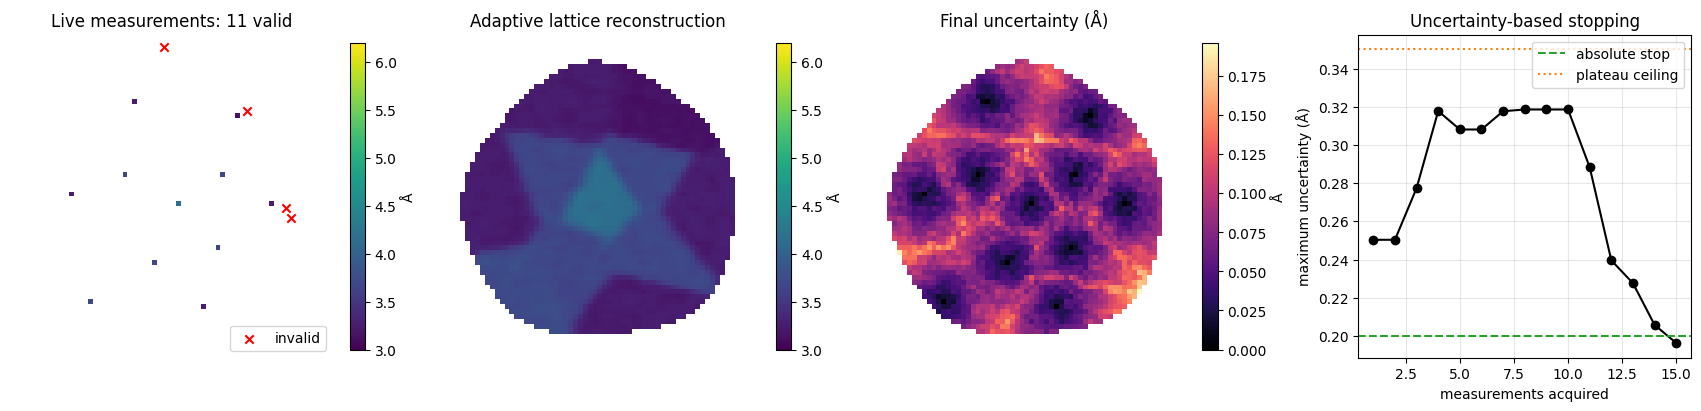

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4), constrained_layout=True)
measured_display = np.where(valid_measured, measured_values, np.nan)
image0 = axes[0].imshow(measured_display, cmap='viridis', vmin=3.0, vmax=6.2)
axes[0].scatter(*np.nonzero(invalid_measured)[::-1], marker='x', color='red', label='invalid')
axes[0].set_title(f'Live measurements: {valid_measured.sum()} valid')
axes[0].legend(loc='lower right')
fig.colorbar(image0, ax=axes[0], fraction=0.046, label='Å')

image1 = axes[1].imshow(reconstruction, cmap='viridis', vmin=3.0, vmax=6.2)
axes[1].set_title('Adaptive lattice reconstruction')
fig.colorbar(image1, ax=axes[1], fraction=0.046, label='Å')

image2 = axes[2].imshow(uncertainty_A, cmap='magma')
axes[2].set_title('Final uncertainty (Å)')
fig.colorbar(image2, ax=axes[2], fraction=0.046, label='Å')

axes[3].plot(
    np.arange(1, len(uncertainty_history) + 1),
    uncertainty_history, marker='o', color='black',
)
axes[3].axhline(absolute_uncertainty_target_A, color='tab:green', linestyle='--', label='absolute stop')
axes[3].axhline(plateau_ceiling_A, color='tab:orange', linestyle=':', label='plateau ceiling')
axes[3].set_xlabel('measurements acquired')
axes[3].set_ylabel('maximum uncertainty (Å)')
axes[3].set_title('Uncertainty-based stopping')
axes[3].grid(alpha=0.3)
axes[3].legend()
for ax in axes[:3]:
    ax.axis('off')

map_range = (
    float(np.nanmin(reconstruction[region_mask])),
    float(np.nanmax(reconstruction[region_mask])),
)
budget_fraction = 100 * len(map_measurements) / max(int(region_mask.sum()), 1)
final_uncertainty = float(uncertainty_history[-1])
invalid_count = int(invalid_measured.sum())

display(map_measurements.round(4))
display(Markdown(
    f"""#### Exercise 2 conclusions (live data)

- **Budget and outcome.** The hard cap was **{maximum_budget} diffraction patterns**, chosen to stay small relative to the **{int(region_mask.sum())} HAADF particle pixels** while allowing a center anchor, one background validity control, and adaptive refinement. The sampler used **{len(map_measurements)} patterns ({budget_fraction:.2f}% of that pixel count)** and stopped because **{stop_reason}**.
- **Early stopping.** The predeclared rule required at least {minimum_before_stop} acquisitions, then stopped at either maximum uncertainty ≤ {absolute_uncertainty_target_A:.2f} Å or a {plateau_window}-step reduction < {plateau_reduction_A:.2f} Å once uncertainty was already below {plateau_ceiling_A:.2f} Å. The final maximum was **{final_uncertainty:.3f} Å**.
- **Adaptive map.** The reconstructed crystalline support spans **{map_range[0]:.3f}–{map_range[1]:.3f} Å** from **{int(valid_measured.sum())} valid full-array diffraction measurements**.
- **Noncrystalline/invalid treatment.** **{invalid_count} acquisition(s)** lacked a trustworthy particle {{200}} peak or matching particle identity. They are retained as red-cross validity observations, excluded from the scalar DCT fit, and displayed as `NaN` rather than being assigned an invented lattice parameter. Unmeasured locations remain reconstruction estimates with an explicit uncertainty map.
"""
))


In [27]:
# Close only this notebook's MCP client connection; do not alter any service.
await mcp_client.__aexit__(None, None, None)
print("Notebook MCP client closed; live services left running and unchanged.")


Notebook MCP client closed; live services left running and unchanged.
